# PFE Master — Plateforme BI pour la Prévision des Revenus Postaux
## Module IA : Prévision Séries Temporelles ML/DL

---

| Jeu de données | Fichier | Feuille | Cibles | Dimension |
|---|---|---|---|---|
| **Export** | `dépôt2026_nettoyé.xlsx` | `export` | poids, CA | Pays Destination |
| **National** | `dépôt2026_nettoyé.xlsx` | `national` | poids, CA | Region Depot |
| **Import** | `import.xls` | `Feuil1` | poids | Pays origine |

### Modèles
| Catégorie | Algorithmes |
|---|---|
| Statistiques | AutoARIMA · AutoETS · AutoTheta (StatsForecast) |
| Prophet | Prophet (Meta) |
| Gradient Boosting | LightGBM + Optuna · XGBoost · CatBoost |
| Deep Learning | N-HiTS · PatchTST · LSTM · TFT (NeuralForecast) |
| Explicabilité | SHAP |

In [1]:
import subprocess, sys

# Pin numpy < 2.0 FIRST — prevents numpy/pandas conflict caused by neuralforecast deps
for pkg in ['numpy>=1.24,<2.0', 'pandas>=2.0,<3.0', 'nbformat>=4.2.0']:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                       capture_output=True)
    status = 'OK' if r.returncode == 0 else 'FAIL'
    print(f'  [{status}] {pkg}')

packages = [
    'neuralforecast', 'statsforecast', 'prophet', 'cmdstanpy',
    'lightgbm', 'xgboost', 'catboost', 'optuna', 'shap',
    'plotly', 'openpyxl', 'python-calamine', 'scikit-learn',
    'matplotlib', 'seaborn', 'tqdm', 'kaleido',
]
for pkg in packages:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                       capture_output=True)
    status = 'OK' if r.returncode == 0 else 'FAIL'
    print(f'  [{status}] {pkg}')

# Install CmdStan binary (required by Prophet — only needed once)
try:
    import cmdstanpy
    cmdstanpy.install_cmdstan(progress=False, overwrite=False)
    print('  [OK] CmdStan binary')
except Exception as e:
    print(f'  [WARN] CmdStan install: {e}')

print('Installation done.')
print()
print('*** RESTART THE KERNEL NOW (Kernel > Restart) before running the next cell ***')

  [OK] numpy>=1.24,<2.0
  [OK] pandas>=2.0,<3.0
  [OK] nbformat>=4.2.0
  [OK] neuralforecast
  [OK] statsforecast
  [OK] prophet
  [OK] cmdstanpy
  [OK] lightgbm
  [OK] xgboost
  [OK] catboost
  [OK] optuna
  [OK] shap
  [OK] plotly
  [OK] openpyxl
  [OK] python-calamine
  [OK] scikit-learn
  [OK] matplotlib
  [OK] seaborn
  [OK] tqdm
  [OK] kaleido
CmdStan install directory: C:\Users\USER\.cmdstan
Installing CmdStan version: 2.39.0
Download successful, file: C:\Users\USER\AppData\Local\Temp\tmpxzjn3vcr
Extracting distribution


15:42:49 - cmdstanpy - WARNING - CmdStan installation failed.
Command "make build" failed
Command: ['mingw32-make', 'build', '-j1']
failed with error [WinError 2] Le fichier spécifié est introuvable



Unpacked download as cmdstan-2.39.0
Building version cmdstan-2.39.0, may take several minutes, depending on your system.
  [OK] CmdStan binary
Installation done.

*** RESTART THE KERNEL NOW (Kernel > Restart) before running the next cell ***


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, unicodedata, os
warnings.filterwarnings('ignore')
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
shap.initjs()

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, PatchTST, LSTM as NF_LSTM, TFT
from neuralforecast.losses.pytorch import MAE as NF_MAE

from prophet import Prophet
from tqdm import tqdm

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='husl')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f'pandas {pd.__version__} | numpy {np.__version__} — ready.')

pandas 2.3.3 | numpy 2.4.6 — ready.


---
## Partie 1 — Exploration des Données

In [3]:
DEPOT_FILE   = 'dépôt2026_nettoyé.xlsx'
IMPORT_FILE  = 'import.xls'

# Sheets to use — all others ignored
DEPOT_SHEETS = ['export', 'national']   # Feuil3, Sheet1 excluded
IMPORT_SHEET = 'Feuil1'

def normalize(s):
    if not isinstance(s, str): return str(s)
    import unicodedata
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    return s.lower().strip()

def find_col(df, keywords, exclude=None):
    exclude = exclude or []
    col_map = {normalize(c): c for c in df.columns}
    # Pass 1: exact normalized match (prevents 'ca' matching 'EDI_Cause')
    for kw in keywords:
        kw_n = normalize(kw)
        if kw_n in col_map and col_map[kw_n] not in exclude:
            return col_map[kw_n]
    # Pass 2: substring match — only for keywords longer than 2 chars
    for kw in keywords:
        kw_n = normalize(kw)
        if len(kw_n) <= 2:
            continue
        for norm_name, orig_name in col_map.items():
            if kw_n in norm_name and orig_name not in exclude:
                return orig_name
    return None

def quick_info(df, name):
    print(f'\n--- {name} ---')
    print(f'Shape : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
    print(f'Colonnes: {list(df.columns)}')
    nulls = df.isnull().sum()
    print('Nulls par colonne:')
    print(nulls[nulls > 0].to_string())
    display(df.head(3))

print('=== DEPOT FILE ===')
xl_depot = pd.ExcelFile(DEPOT_FILE, engine='openpyxl')
all_depot_sheets = xl_depot.sheet_names
print('All sheets  :', all_depot_sheets)
print('Used sheets :', DEPOT_SHEETS)
print('Excluded    :', [s for s in all_depot_sheets if s not in DEPOT_SHEETS])

print('\n=== IMPORT FILE ===')
xl_import = pd.ExcelFile(IMPORT_FILE, engine='calamine')
print('All sheets  :', xl_import.sheet_names)
print('Used sheet  :', IMPORT_SHEET)

=== DEPOT FILE ===
All sheets  : ['national', 'export', 'Feuil3', 'Sheet1']
Used sheets : ['export', 'national']
Excluded    : ['Feuil3', 'Sheet1']

=== IMPORT FILE ===
All sheets  : ['Feuil1']
Used sheet  : Feuil1


In [4]:
# Load only the declared sheets — all others skipped
print('Loading Export sheet...')
df_exp_raw = pd.read_excel(DEPOT_FILE, sheet_name='export',   header=2, engine='openpyxl')
quick_info(df_exp_raw, 'Export')

print('\nLoading National sheet...')
df_nat_raw = pd.read_excel(DEPOT_FILE, sheet_name='national', header=2, engine='openpyxl')
quick_info(df_nat_raw, 'National')

print('\nLoading Import sheet (Feuil1)...')
df_imp_raw = pd.read_excel(IMPORT_FILE, sheet_name=IMPORT_SHEET, engine='calamine')
quick_info(df_imp_raw, 'Import')

Loading Export sheet...

--- Export ---
Shape : 16,417 lignes x 33 colonnes
Colonnes: ['MAILITM_FID', 'poids', 'Nom_exp', 'Pre_exp', 'Exp_adresse', 'Exp_cité', 'Exp_code_postale', 'Exp_phone', 'Pays origine', 'Pays Destination', 'CRBT', 'Date depot', 'Mois_depot', 'Annee_depot', 'Bureau depot', 'Region Depot', 'Dernier E', 'Date dernier E', 'Bureau dernier E', 'Region dernier E', 'Bureau next', 'Region Next', 'Intervalle en jours', 'EDI_Event', 'EDI_Date', 'EDI_Cause', 'EDI_action', 'date echec ou livraison', 'sup à 2 kg jusquà 3 kg', 'Pour chaque kg supp ou fractionnement de 1 kg', 'CA', 'CRBT/ORD', 'intervalle liv EDI/dépôt']
Nulls par colonne:
Bureau next                   7
intervalle liv EDI/dépôt    513


,MAILITM_FID,poids,Nom_exp,Pre_exp,Exp_adresse,Exp_cité,Exp_code_postale,Exp_phone,Pays origine,Pays Destination,CRBT,Date depot,Mois_depot,Annee_depot,Bureau depot,Region Depot,Dernier E,Date dernier E,Bureau dernier E,Region dernier E,Bureau next,Region Next,Intervalle en jours,EDI_Event,EDI_Date,EDI_Cause,EDI_action,date echec ou livraison,sup à 2 kg jusquà 3 kg,Pour chaque kg supp ou fractionnement de 1 kg,CA,CRBT/ORD,intervalle liv EDI/dépôt
0,CP202739758TN,3.60,rabiaa hajri,,,,2083,,Tunisia,Algeria,0,2026-01-14 15:09:00,1,2026,CITE GHAZALA,ARIANA,Inserer envoi dans le sac (Otb),2026-01-15 23:57:00,TUNIS CENTRE DES COLIS POSTAUX,CENTRAL_C,NaN,,1,Echec de tentative de livraison (Inb),2026-01-27 09:42:00,Destinataire non joignable à adr. indiquée : b...,"Envoi gardé, le destinataire a été avisé",_,36.135828,5,41.135828,Ordinaire,12.772917
1,CP327391025TN,2.98,HASNA KADRI,,RTE SOUKRA KM4 BP 50,SFAX,3052,58058272,Tunisia,Algeria,0,2026-04-06 12:17:00,4,2026,Agence Poste-Colis Sfax,SFAX,Inserer envoi dans le sac (Otb),2026-04-08 00:07:00,TUNIS CENTRE DES COLIS POSTAUX,CENTRAL_C,NaN,,2,Envoi Livré,2026-04-15 15:18:00,X,X,_,36.135828,5,36.135828,Ordinaire,9.125694
2,CP301230290TN,3.84,FERIEL AOUIDIDI,,,,2073,,Tunisia,Algeria,0,2026-01-08 15:06:00,1,2026,BORJ LOUZIR,ARIANA,Inserer envoi dans le sac (Otb),2026-01-14 08:52:00,TUNIS CENTRE DES COLIS POSTAUX,CENTRAL_C,NaN,,6,Envoi Livré,2026-01-22 08:39:00,X,X,_,36.135828,5,41.135828,Ordinaire,13.731250



Loading National sheet...

--- National ---
Shape : 24,003 lignes x 33 colonnes
Colonnes: ['MAILITM_FID', 'poids', 'Nom_exp', 'Pre_exp', 'Exp_adresse', 'Exp_cité', 'Exp_code_postale', 'Exp_phone', 'Pays origine', 'Pays Destination', 'CRBT', 'Date depot', 'Mois_depot', 'Annee_depot', 'Bureau depot', 'Region Depot', 'Dernier E', 'Date dernier E', 'Bureau dernier E', 'Region dernier E', 'Bureau next', 'Region Next', 'Intervalle en jours', 'EDI_Event', 'EDI_Date', 'EDI_Cause', 'EDI_action', 'date echec ou livraison', 'sup à 2 kg jusquà 3 kg', 'Pour chaque kg supp ou fractionnement de 1 kg', 'CA', 'CRBT/ORD', 'intervalle liv EDI/dépôt']
Nulls par colonne:
Bureau next    1


,MAILITM_FID,poids,Nom_exp,Pre_exp,Exp_adresse,Exp_cité,Exp_code_postale,Exp_phone,Pays origine,Pays Destination,CRBT,Date depot,Mois_depot,Annee_depot,Bureau depot,Region Depot,Dernier E,Date dernier E,Bureau dernier E,Region dernier E,Bureau next,Region Next,Intervalle en jours,EDI_Event,EDI_Date,EDI_Cause,EDI_action,date echec ou livraison,sup à 2 kg jusquà 3 kg,Pour chaque kg supp ou fractionnement de 1 kg,CA,CRBT/ORD,intervalle liv EDI/dépôt
0,CP327375230TN,11.24,CPR /205721,,,SFAX,3000,,Tunisia,Tunisia,0.00,2026-02-10 15:55:00,2,2026,Agence Poste-Colis Sfax,SFAX,Envoi Livré,2026-02-11 11:05:00,Agence Colis-Rapid Kef,KEF,,,1,X,X,X,X,Feb 11 2026 11:05,4.3,0.3,7.0,Ordinaire,0.798611
1,CP327375226TN,11.24,CPR /205721,,,SFAX,3000,,Tunisia,Tunisia,0.00,2026-02-10 15:55:00,2,2026,Agence Poste-Colis Sfax,SFAX,Envoi Livré,2026-02-11 11:05:00,Agence Colis-Rapid Kef,KEF,,,1,X,X,X,X,Feb 11 2026 11:05,4.3,0.3,7.0,Ordinaire,0.798611
2,CP327375212TN,6.60,LAHIANI PIECES AUTOS / 201597,,,SFAX,3000,,Tunisia,Tunisia,336.34,2026-02-10 15:52:00,2,2026,Agence Poste-Colis Sfax,SFAX,Envoi Livré,2026-02-11 11:05:00,Agence Colis-Rapid Kef,KEF,,,1,X,X,X,X,Feb 11 2026 11:05,4.3,0.3,5.5,CRBT,0.800694



Loading Import sheet (Feuil1)...

--- Import ---
Shape : 5,466 lignes x 28 colonnes
Colonnes: ['MAILITM_FID', 'poids', 'Nom_exp', 'Pre_exp', 'Exp_adresse', 'Exp_cité', 'Exp_code_postale', 'Exp_phone', 'Pays origine', 'Pays Destination', 'CRBT', 'Date depot', 'Mois_depot', 'Annee_depot', 'Bureau depot', 'Region Depot', 'Dernier E', 'Date dernier E', 'Bureau dernier E', 'Region dernier E', 'Bureau next', 'Region Next', 'Intervalle en jours', 'EDI_Event', 'EDI_Date', 'EDI_Cause', 'EDI_action', 'date echec ou livraison']
Nulls par colonne:
Series([], )


,MAILITM_FID,poids,Nom_exp,Pre_exp,Exp_adresse,Exp_cité,Exp_code_postale,Exp_phone,Pays origine,Pays Destination,CRBT,Date depot,Mois_depot,Annee_depot,Bureau depot,Region Depot,Dernier E,Date dernier E,Bureau dernier E,Region dernier E,Bureau next,Region Next,Intervalle en jours,EDI_Event,EDI_Date,EDI_Cause,EDI_action,date echec ou livraison
0,CA002896378PT,4.140,,,,,,,Portugal,Tunisia,0.0,2026-01-21 07:55:00,1,2026,TUNIS CENTRE DES COLIS POSTAUX,CENTRAL_C,Envoi Livré,2026-01-23 10:04:00,SBEITLA,KASSERINE,,,2,Send item abroad (EDI-received),2026-01-15 17:37:00,X,X,Jan 23 2026 10:04
1,CA004147871US,0.450,,,,,,,United States of America (the),Tunisia,0.0,2026-01-07 08:17:00,1,2026,TUNIS CENTRE DES COLIS POSTAUX,CENTRAL_C,Envoi Livré,2026-01-09 09:19:00,MATEUR,BIZERTE,,,2,Send item abroad (EDI-received),2026-01-02 15:20:00,X,X,Jan 9 2026 9:19
2,CA004386134US,3.810,,,,,,,United States of America (the),Tunisia,0.0,2026-01-26 09:29:00,1,2026,TUNIS CENTRE DES COLIS POSTAUX,CENTRAL_C,Envoi Livré,2026-02-19 10:42:00,MEGRINE,BEN AROUS,,,24,Send item abroad (EDI-received),2026-01-12 09:16:00,X,X,Jan 29 2026 2:30


In [5]:
df_exp_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16417 entries, 0 to 16416
Data columns (total 33 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   MAILITM_FID                                    16417 non-null  object        
 1   poids                                          16417 non-null  float64       
 2   Nom_exp                                        16417 non-null  object        
 3   Pre_exp                                        16417 non-null  object        
 4   Exp_adresse                                    16417 non-null  object        
 5   Exp_cité                                       16417 non-null  object        
 6   Exp_code_postale                               16417 non-null  object        
 7   Exp_phone                                      16417 non-null  object        
 8   Pays origine                                   16417 non

---
## Partie 2 — Prétraitement & Agrégation Mensuelle

In [6]:
def preprocess(df, group_keywords, has_ca=True, dataset_name='ds'):
    """
    Aggregate raw transactional data to DAILY (business days only).
    Uses 'Date depot' for the timestamp; weekends are dropped.
    """
    df = df.copy()

    poids_col = find_col(df, ['poids', 'masse', 'weight'])
    date_col  = find_col(df, ['date depot', 'date_depot'])
    id_col    = find_col(df, ['mailitm', 'fid', 'id', 'numero'])
    group_col = find_col(df, group_keywords)
    ca_col    = find_col(df, ['CA', 'chiffre affaires', 'revenue']) if has_ca else None

    print(f'[{dataset_name}]')
    print(f'  poids={poids_col}, date={date_col}')
    print(f'  group={group_col}, ca={ca_col}, id={id_col}')

    if not date_col:
        raise ValueError(f'[{dataset_name}] No date column found.')

    # Parse date, truncate to calendar day
    df['ds'] = pd.to_datetime(df[date_col], errors='coerce').dt.normalize()
    df = df.dropna(subset=['ds'])

    # Keep only business days (Mon=0 … Fri=4)
    df = df[df['ds'].dt.dayofweek < 5]

    # Group column
    if group_col:
        df['unique_id'] = (df[group_col].astype(str)
                           .str.strip().str.upper().fillna('INCONNU'))
    else:
        df['unique_id'] = dataset_name

    # Numeric cleanup
    if poids_col:
        df[poids_col] = pd.to_numeric(df[poids_col], errors='coerce').fillna(0).clip(lower=0)
    if ca_col:
        df[ca_col] = pd.to_numeric(df[ca_col], errors='coerce').fillna(0).clip(lower=0)

    # Aggregate to daily
    agg = {}
    if poids_col: agg[poids_col] = 'sum'
    if ca_col:    agg[ca_col]    = 'sum'
    if id_col:    agg[id_col]    = 'count'

    df_daily = df.groupby(['ds', 'unique_id']).agg(agg).reset_index()

    rename = {}
    if poids_col: rename[poids_col] = 'poids'
    if ca_col:    rename[ca_col]    = 'CA'
    if id_col:    rename[id_col]    = 'nb_envois'
    df_daily = df_daily.rename(columns=rename)
    df_daily = df_daily.sort_values(['unique_id', 'ds']).reset_index(drop=True)

    col_info = {'has_ca': ca_col is not None}
    n_series = df_daily['unique_id'].nunique()
    print(f'  -> {df_daily.shape[0]:,} records | {n_series} series | '
          f'{df_daily["ds"].min().date()} -> {df_daily["ds"].max().date()}')
    return df_daily, col_info

print('Preprocess ready (daily business days).')

Preprocess ready (daily business days).


In [7]:
df_export, info_export = preprocess(
    df_exp_raw,
    group_keywords=['pays destination', 'destination'],
    has_ca=True, dataset_name='Export'
)
df_export.to_csv('export_cleaned.csv', index=False)
print('Saved → export_cleaned.csv')
display(df_export.describe())

[Export]
  poids=poids, date=Date depot
  group=Pays Destination, ca=CA, id=MAILITM_FID
  -> 1,741 records | 64 series | 2026-01-02 -> 2026-04-30
Saved → export_cleaned.csv


,ds,poids,CA,nb_envois
count,1741,1741.000000,1741.000000,1741.000000
mean,2026-02-24 22:26:32.188397568,103.944380,1257.845939,9.350373
min,2026-01-02 00:00:00,1.530000,36.135828,1.000000
25%,2026-01-28 00:00:00,9.750000,149.050086,1.000000
50%,2026-02-19 00:00:00,26.600000,387.321216,2.000000
75%,2026-03-25 00:00:00,97.925000,1242.963543,10.000000
max,2026-04-30 00:00:00,2762.472000,23889.860680,214.000000
std,NaN,210.872236,2225.662975,17.764589


In [8]:
df_national, info_national = preprocess(
    df_nat_raw,
    group_keywords=['region depot', 'region', 'bureau depot'],
    has_ca=True, dataset_name='National'
)
df_national.to_csv('national_cleaned.csv', index=False)
print('Saved → national_cleaned.csv')
display(df_national.describe())

[National]
  poids=poids, date=Date depot
  group=Region Depot, ca=CA, id=MAILITM_FID
  -> 1,898 records | 25 series | 2026-01-02 -> 2026-04-30
Saved → national_cleaned.csv


,ds,poids,CA,nb_envois
count,1898,1898.000000,1898.000000,1898.000000
mean,2026-03-02 02:15:02.845100032,95.808526,73.987092,12.574816
min,2026-01-02 00:00:00,0.020000,4.300000,1.000000
25%,2026-02-02 00:00:00,17.355000,19.825000,4.000000
50%,2026-03-02 00:00:00,40.307500,38.500000,7.000000
75%,2026-04-01 00:00:00,88.045000,77.175000,14.000000
max,2026-04-30 00:00:00,1698.480000,1169.900000,188.000000
std,NaN,176.248751,111.442355,16.800355


In [9]:
df_import, info_import = preprocess(
    df_imp_raw,
    group_keywords=['pays origine', 'origine', 'origin'],
    has_ca=False, dataset_name='Import'
)
df_import.to_csv('import_cleaned.csv', index=False)
print('Saved → import_cleaned.csv')
display(df_import.describe())

[Import]
  poids=poids, date=Date depot
  group=Pays origine, ca=None, id=MAILITM_FID
  -> 1,014 records | 66 series | 2026-01-02 -> 2026-04-30
Saved → import_cleaned.csv


,ds,poids,nb_envois
count,1014,1014.000000,1014.000000
mean,2026-02-26 19:28:45.443787008,48.393340,5.390533
min,2026-01-02 00:00:00,0.025000,1.000000
25%,2026-01-29 00:00:00,5.000000,1.000000
50%,2026-02-23 00:00:00,16.105000,2.000000
75%,2026-03-24 18:00:00,39.532500,5.000000
max,2026-04-30 00:00:00,8275.000000,111.000000
std,NaN,269.019332,10.433608


---
## Partie 3 — Analyse Exploratoire (EDA)

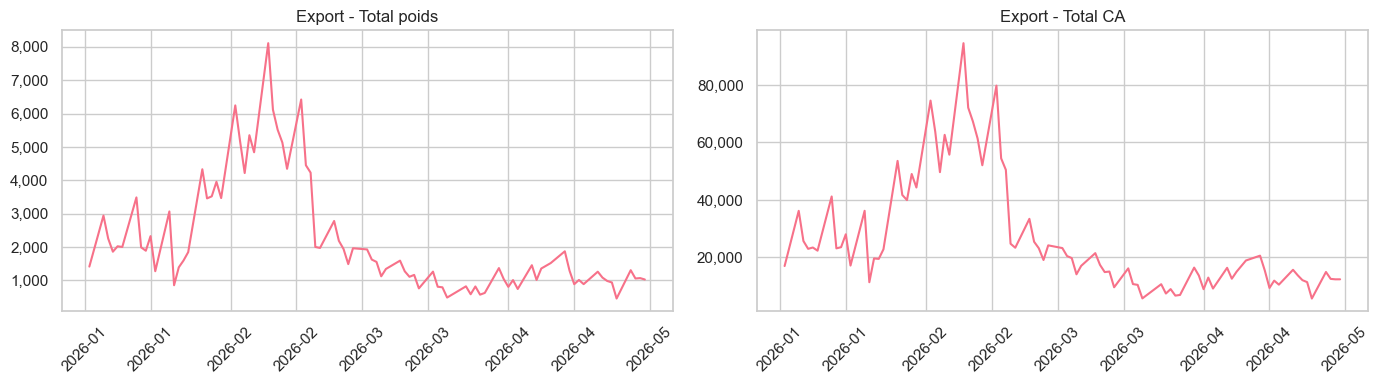

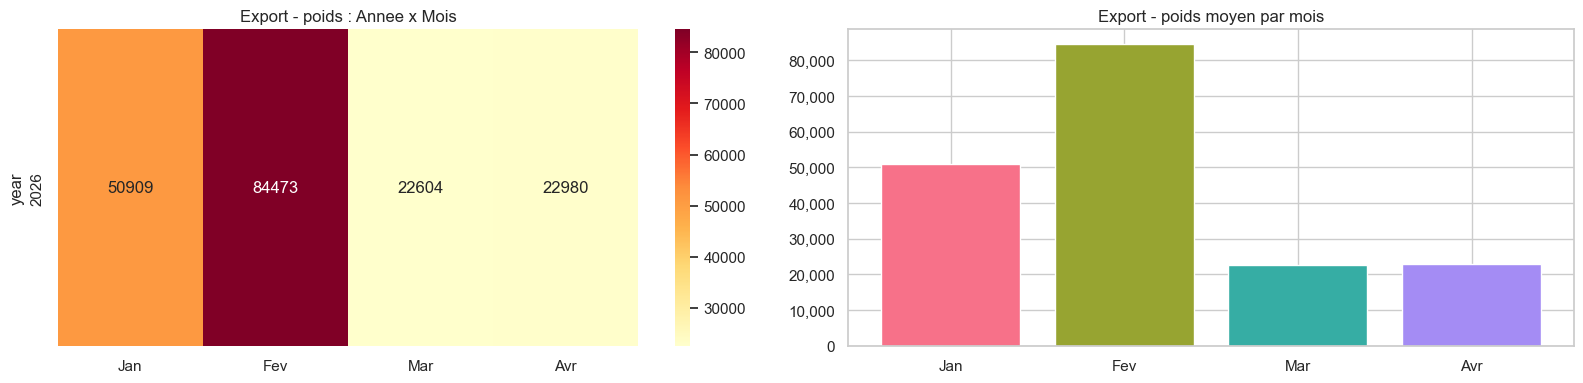

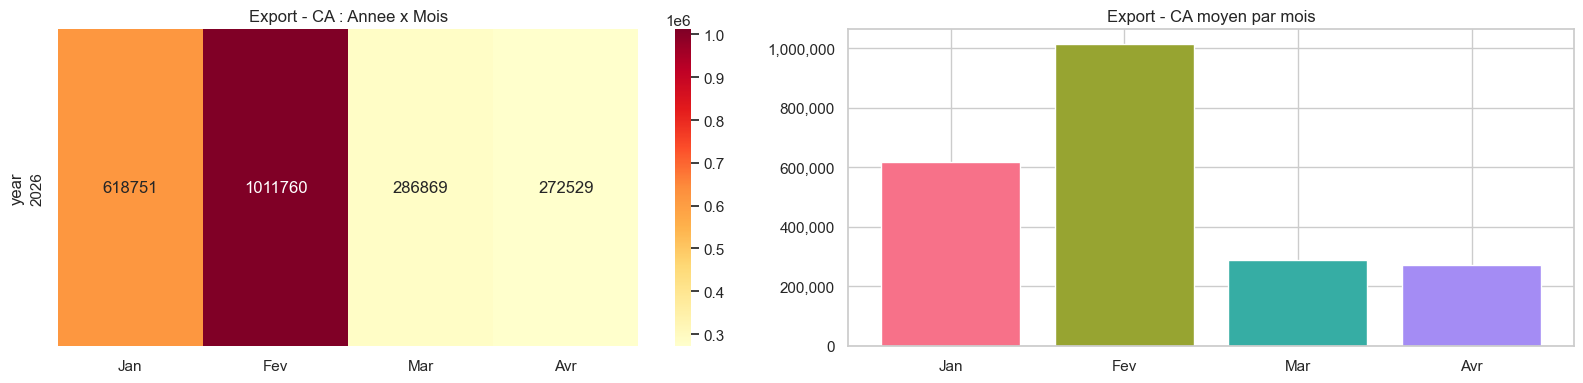

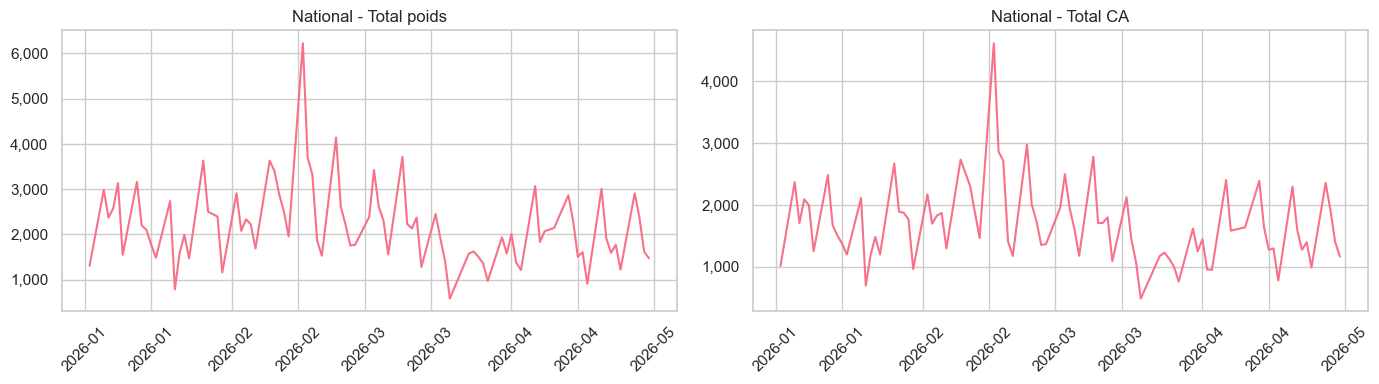

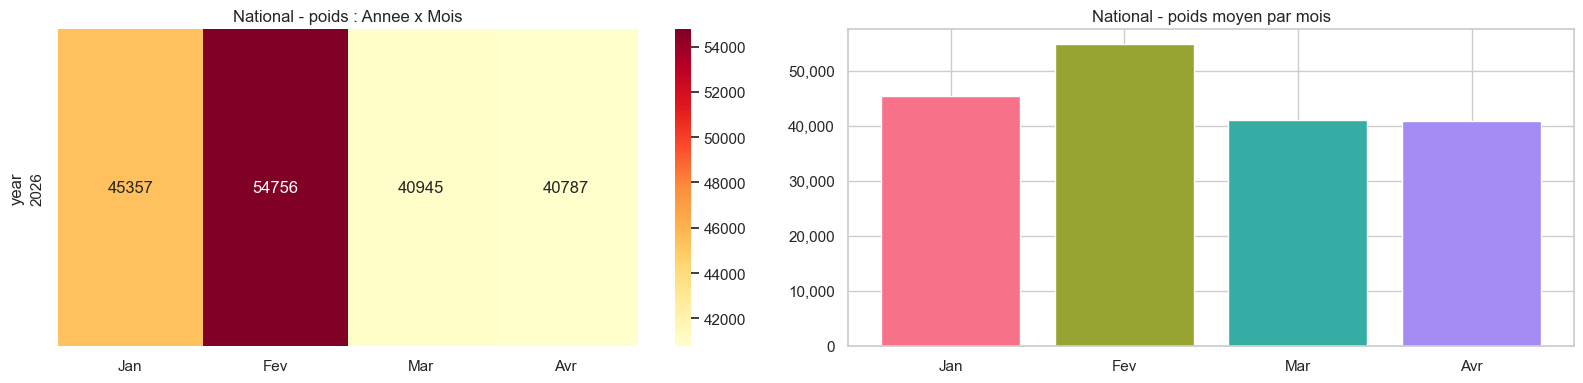

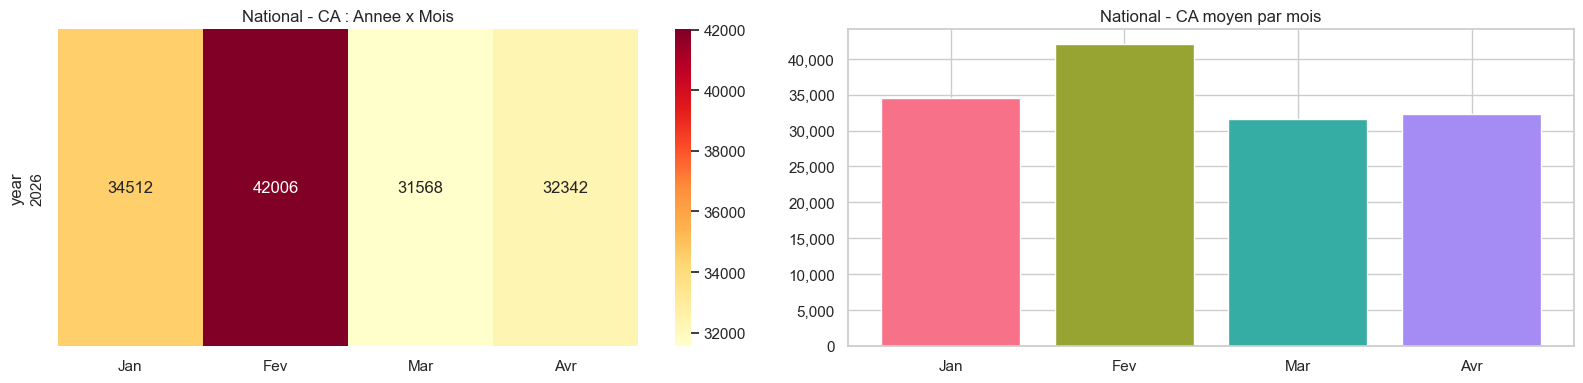

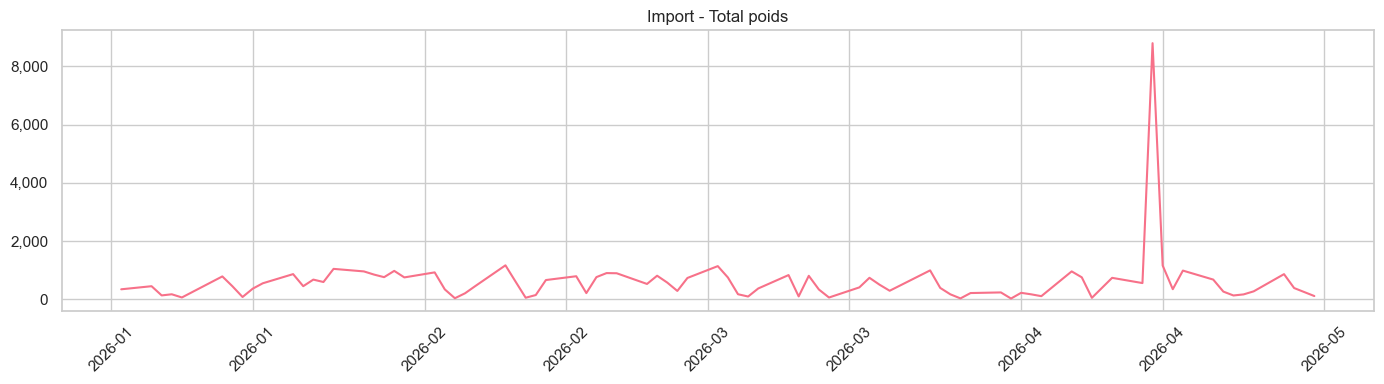

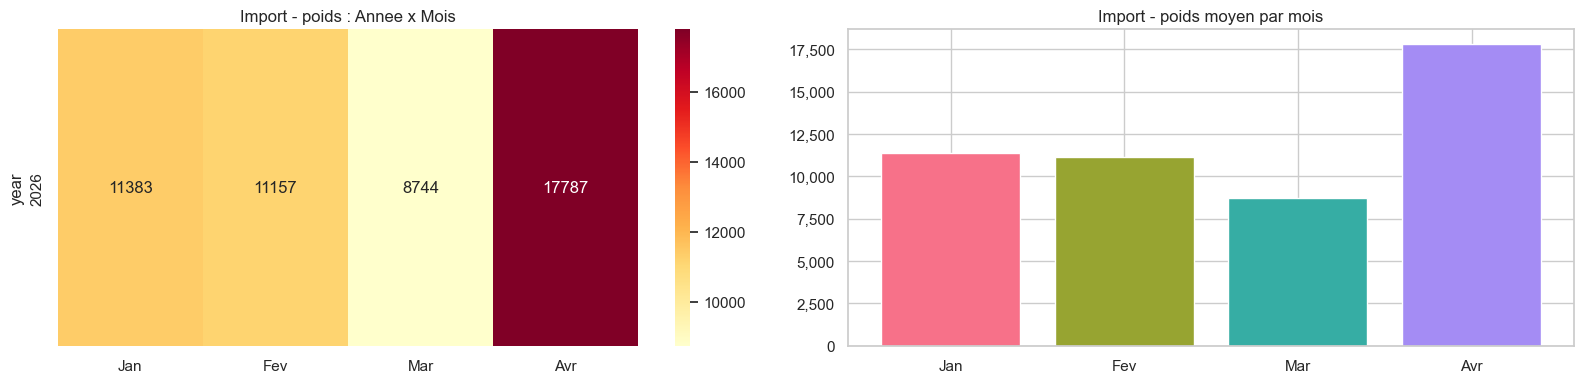

In [10]:
def plot_aggregated(df, targets, dataset_name):
    total = df.groupby('ds')[targets].sum().reset_index()
    fig, axes = plt.subplots(1, len(targets), figsize=(14, 4))
    if len(targets) == 1: axes = [axes]
    for ax, col in zip(axes, targets):
        ax.plot(total['ds'], total[col], lw=1.5)
        ax.set_title(f'{dataset_name} - Total {col}')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=45)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    plt.tight_layout(); plt.show()

def plot_top_series(df, target, dataset_name, top_n=8):
    if target not in df.columns: return
    top_ids = df.groupby('unique_id')[target].sum().nlargest(top_n).index.tolist()
    subset  = df[df['unique_id'].isin(top_ids)]
    fig = px.line(subset, x='ds', y=target, color='unique_id',
                  title=f'{dataset_name} - {target} (Top {top_n})',
                  template='plotly_white')
    fig.update_traces(line=dict(width=1.5))
    fig.show()

def seasonality_heatmap(df, target, dataset_name):
    if target not in df.columns: return
    total = df.groupby('ds')[target].sum().reset_index()
    total['year']  = total['ds'].dt.year
    total['month'] = total['ds'].dt.month

    # Aggregate to monthly totals first (daily data has many rows per month)
    monthly = total.groupby(['year', 'month'])[target].sum().reset_index()
    pivot = monthly.pivot(index='year', columns='month', values=target)
    month_labels = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
    pivot.columns = [month_labels[c-1] for c in pivot.columns]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax1)
    ax1.set_title(f'{dataset_name} - {target} : Annee x Mois')

    monthly_avg   = monthly.groupby('month')[target].mean()
    present_labels = [month_labels[m-1] for m in monthly_avg.index]
    ax2.bar(present_labels, monthly_avg.values,
            color=sns.color_palette('husl', len(present_labels)))
    ax2.set_title(f'{dataset_name} - {target} moyen par mois')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    plt.tight_layout(); plt.show()

for ds_name, df_ds in [('Export', df_export), ('National', df_national), ('Import', df_import)]:
    tgts = [c for c in ['poids', 'CA'] if c in df_ds.columns]
    plot_aggregated(df_ds, tgts, ds_name)
    for t in tgts:
        plot_top_series(df_ds, t, ds_name)
        seasonality_heatmap(df_ds, t, ds_name)

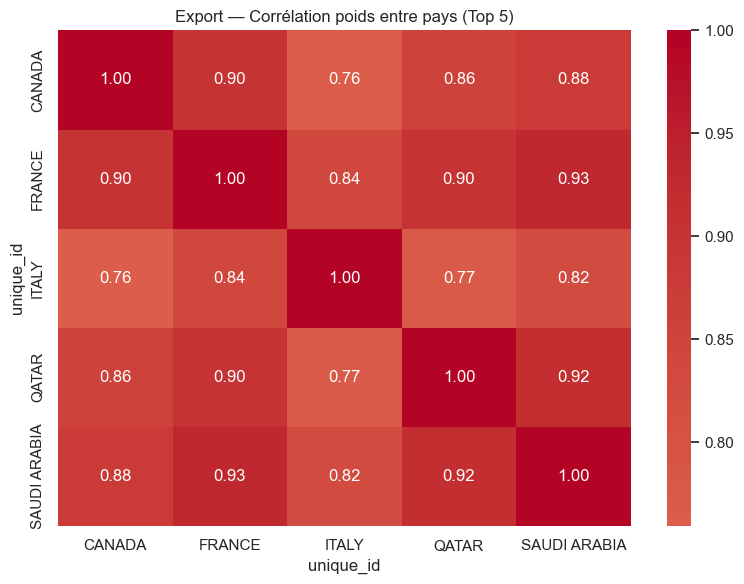

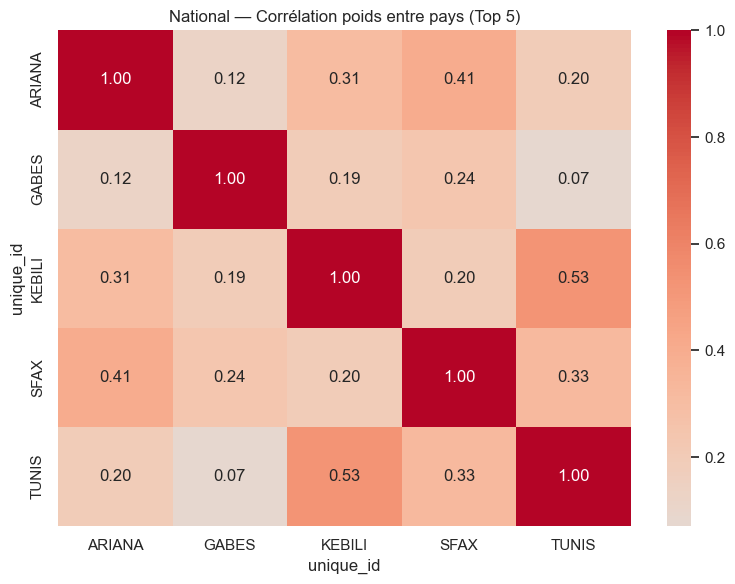

In [11]:
# Correlation heatmap between targets (where applicable)
def corr_by_country(df, targets, dataset_name, top_n=5):
    if len(targets) < 2: return
    top_ids = df.groupby('unique_id')['poids'].sum().nlargest(top_n).index
    sub = df[df['unique_id'].isin(top_ids)]
    pivot = sub.pivot_table(index='ds', columns='unique_id', values='poids')
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title(f'{dataset_name} — Corrélation poids entre pays (Top {top_n})')
    plt.tight_layout(); plt.show()

corr_by_country(df_export,   ['poids', 'CA'], 'Export')
corr_by_country(df_national, ['poids', 'CA'], 'National')

---
## Partie 4 — Ingénierie des Caractéristiques

In [12]:
def add_features(df, target, lags=(1, 2, 3, 5, 10, 22), windows=(5, 10, 22)):
    """
    Add temporal, lag, and rolling features for daily business-day data.
    Lags: 1d, 2d, 3d, 1w, 2w, ~1month.
    Windows: 1w, 2w, ~1month rolling stats.
    """
    df = df.sort_values(['unique_id', 'ds']).copy()

    # Temporal features
    df['dayofweek'] = df['ds'].dt.dayofweek          # 0=Mon ... 4=Fri
    df['dayofmonth'] = df['ds'].dt.day
    df['month']     = df['ds'].dt.month
    df['quarter']   = df['ds'].dt.quarter
    df['year']      = df['ds'].dt.year
    df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 5)
    df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 5)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['trend']     = (df['ds'] - df['ds'].min()).dt.days

    # Lag features
    grp = df.groupby('unique_id')[target]
    for lag in lags:
        df[f'lag_{lag}'] = grp.shift(lag)

    # Rolling statistics (shift 1 to avoid leakage)
    for w in windows:
        df[f'roll_mean_{w}'] = grp.transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        df[f'roll_std_{w}']  = grp.transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).std().fillna(0))
        df[f'roll_max_{w}']  = grp.transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).max())

    # Week-over-week (5 business days ago)
    df['wow_lag']   = grp.shift(5)
    df['wow_ratio'] = df[target] / (df['wow_lag'].replace(0, np.nan))

    # Entity encoding
    le = LabelEncoder()
    df['uid_enc'] = le.fit_transform(df['unique_id'].astype(str))

    return df.dropna(subset=[f'lag_{max(lags)}']).reset_index(drop=True)

print('Feature engineering ready (daily: lags 1/2/3/5/10/22, windows 5/10/22).')

Feature engineering ready (daily: lags 1/2/3/5/10/22, windows 5/10/22).


---
## Partie 5 — Métriques & Utilitaires

In [13]:
HORIZON     = 30    # business days for model evaluation (~6 weeks)
HORIZON_FUT = 60    # business days for future forecast (~3 months)
MIN_OBS     = 20    # min business-day observations per series (~4 weeks)
RUN_NEURAL  = True  # set False to skip neural networks

ALL_RESULTS   = {}
ALL_FORECASTS = {}
ML_MODELS     = {}

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)) * 100

def compute_metrics(y_true, y_pred, model_name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return {
        'model': model_name,
        'MAE':   mean_absolute_error(y_true, y_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_true, y_pred)),
        'SMAPE': smape(y_true, y_pred),
        'R2':    r2_score(y_true, y_pred),
    }

def to_nixtla(df_daily, target):
    ndf = df_daily[['unique_id', 'ds', target]].rename(columns={target: 'y'}).copy()
    ndf = ndf.dropna(subset=['y'])
    ndf['y'] = ndf['y'].clip(lower=0)
    counts = ndf.groupby('unique_id')['ds'].count()
    valid  = counts[counts >= MIN_OBS].index
    ndf    = ndf[ndf['unique_id'].isin(valid)].sort_values(['unique_id', 'ds'])
    print(f'  Nixtla -> {len(ndf):,} rows | {ndf["unique_id"].nunique()} series')
    return ndf

def train_test_nixtla(ndf, horizon=HORIZON):
    # Use actual sorted dates — robust to business day gaps
    all_dates = sorted(ndf['ds'].unique())
    n = len(all_dates)
    h = min(horizon, max(5, n - 20))   # keep at least 20 days for training
    cutoff = all_dates[-h]
    train  = ndf[ndf['ds'] <  cutoff].copy()
    test   = ndf[ndf['ds'] >= cutoff].copy()
    print(f'  Train: {train["ds"].min().date()} -> {train["ds"].max().date()} '
          f'({train["ds"].nunique()} days) | '
          f'Test: {test["ds"].min().date()} -> {test["ds"].max().date()} '
          f'({test["ds"].nunique()} days)')
    return train, test

print(f'Config ready: HORIZON={HORIZON}bd eval | HORIZON_FUT={HORIZON_FUT}bd future | MIN_OBS={MIN_OBS}')

Config ready: HORIZON=30bd eval | HORIZON_FUT=60bd future | MIN_OBS=20


---
## Partie 6 — Modèles Statistiques (StatsForecast)
AutoARIMA, AutoETS, AutoTheta — baselines statistiques rapides.

In [14]:
def run_statsforecast(train_nf, test_nf, horizon, key):
    n_days = train_nf['ds'].nunique()
    # Weekly seasonality needs >= 10 days (2 weeks), ETS needs >= 24 months skip it
    season_len = 5 if n_days >= 10 else 1
    models = [AutoARIMA(season_length=season_len),
              AutoTheta(season_length=season_len)]

    print(f'  [StatsForecast] {train_nf["unique_id"].nunique()} series | '
          f'{n_days} train days | season_length={season_len}')
    sf = StatsForecast(
        models=models, freq='B', n_jobs=-1,
        fallback_model=AutoTheta(season_length=1)
    )
    sf.fit(train_nf)
    forecast = sf.predict(h=horizon)
    merged   = test_nf.merge(forecast, on=['unique_id', 'ds'], how='inner')
    metrics  = []
    for col in ['AutoARIMA', 'AutoTheta']:
        if col not in merged.columns: continue
        sub = merged.dropna(subset=[col])
        if len(sub) == 0: continue
        m = compute_metrics(sub['y'].values, sub[col].values, col)
        metrics.append(m)
        print(f'    {col}: SMAPE={m["SMAPE"]:.2f}% | RMSE={m["RMSE"]:,.1f}')
    ALL_RESULTS.setdefault(key, []).extend(metrics)
    ALL_FORECASTS[f'{key}_sf'] = forecast
    return forecast, metrics

print('StatsForecast pipeline ready (freq=B, season=5).')

StatsForecast pipeline ready (freq=B, season=5).


In [15]:
# Prophet disabled — CmdStan backend not available.
PROPHET_AVAILABLE = False
print("[Prophet] Disabled — skipping.")

def run_prophet(train_nf, test_nf, horizon, key):
    print("  [Prophet] Skipped.")
    return pd.DataFrame()

[Prophet] Disabled — skipping.


In [16]:
# Prophet disabled — CmdStan backend not available.
PROPHET_AVAILABLE = False
print("[Prophet] Disabled — skipping.")

def run_prophet(train_nf, test_nf, horizon, key):
    print("  [Prophet] Skipped.")
    return pd.DataFrame()

[Prophet] Disabled — skipping.


---
## Partie 8 — Gradient Boosting : LightGBM + XGBoost + CatBoost avec Optuna

In [17]:
def lgb_objective(trial, X_tr, y_tr, X_va, y_va):
    p = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1500),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'learning_rate':     trial.suggest_float('lr', 5e-3, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1
    }
    model = lgb.LGBMRegressor(**p)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)])
    return mean_absolute_error(y_va, model.predict(X_va))


def run_ml_models(train_nf, test_nf, key, n_trials=40):
    print(f'  [ML] building feature matrix...')
    full = pd.concat([train_nf, test_nf]).sort_values(['unique_id', 'ds'])
    df_feat = add_features(full.rename(columns={'y': '_target'}), '_target')
    exclude = {'unique_id', 'ds', '_target', 'yoy_ratio'}
    feat_cols = [c for c in df_feat.columns
                 if c not in exclude and df_feat[c].dtype != object]

    cutoff   = train_nf['ds'].max()
    df_train = df_feat[df_feat['ds'] <= cutoff].dropna(subset=feat_cols)
    df_test  = df_feat[df_feat['ds'] >  cutoff].dropna(subset=feat_cols)
    if len(df_train) == 0 or len(df_test) == 0:
        print('  Not enough data for ML. Skipping.')
        return {}

    X_train, y_train = df_train[feat_cols].values, df_train['_target'].values
    X_test,  y_test  = df_test[feat_cols].values,  df_test['_target'].values
    val_size = max(int(len(X_train) * 0.2), 12)
    X_tr, y_tr = X_train[:-val_size], y_train[:-val_size]
    X_va, y_va = X_train[-val_size:], y_train[-val_size:]

    trained = {}
    metrics = []

    # LightGBM + Optuna
    print(f'  [LightGBM+Optuna] {n_trials} trials...')
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(lambda t: lgb_objective(t, X_tr, y_tr, X_va, y_va),
                   n_trials=n_trials)
    bp = {**study.best_params, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1}
    lgb_m = lgb.LGBMRegressor(**bp)
    lgb_m.fit(X_train, y_train, callbacks=[lgb.log_evaluation(-1)])
    p_lgb = np.clip(lgb_m.predict(X_test), 0, None)
    m_lgb = compute_metrics(y_test, p_lgb, 'LightGBM')
    metrics.append(m_lgb)
    trained['LightGBM'] = (lgb_m, feat_cols, df_test)
    print(f'    LightGBM: SMAPE={m_lgb["SMAPE"]:.2f}% | RMSE={m_lgb["RMSE"]:,.1f}')

    # XGBoost
    print('  [XGBoost]...')
    xgb_m = xgb.XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )
    xgb_m.fit(X_train, y_train, eval_set=[(X_va, y_va)], verbose=False)
    p_xgb = np.clip(xgb_m.predict(X_test), 0, None)
    m_xgb = compute_metrics(y_test, p_xgb, 'XGBoost')
    metrics.append(m_xgb)
    trained['XGBoost'] = (xgb_m, feat_cols, df_test)
    print(f'    XGBoost: SMAPE={m_xgb["SMAPE"]:.2f}% | RMSE={m_xgb["RMSE"]:,.1f}')

    # CatBoost
    print('  [CatBoost]...')
    cat_m = cb.CatBoostRegressor(
        iterations=800, depth=6, learning_rate=0.05,
        loss_function='RMSE', random_seed=RANDOM_STATE, verbose=0
    )
    cat_m.fit(X_train, y_train, eval_set=(X_va, y_va))
    p_cat = np.clip(cat_m.predict(X_test), 0, None)
    m_cat = compute_metrics(y_test, p_cat, 'CatBoost')
    metrics.append(m_cat)
    trained['CatBoost'] = (cat_m, feat_cols, df_test)
    print(f'    CatBoost: SMAPE={m_cat["SMAPE"]:.2f}% | RMSE={m_cat["RMSE"]:,.1f}')

    ALL_RESULTS.setdefault(key, []).extend(metrics)
    return trained

print('ML pipeline ready.')

ML pipeline ready.


---
## Partie 9 — Réseaux de Neurones (NeuralForecast)
N-HiTS · PatchTST (Transformer) · LSTM · TFT

In [18]:
def run_neuralforecast(train_nf, test_nf, horizon, key):
    n_series = train_nf['unique_id'].nunique()
    n_days   = train_nf['ds'].nunique()
    if n_days < MIN_OBS * 2:
        print(f'  [NeuralForecast] Not enough data ({n_days} days). Skipping.')
        return None, []
    print(f'  [NeuralForecast] {n_series} series | {n_days} train days...')
    input_size = min(2 * horizon, n_days // 2, 60)
    models = [
        NHITS(
            h=horizon, input_size=input_size,
            max_steps=300, scaler_type='standard',
            learning_rate=1e-3, batch_size=32,
        ),
        PatchTST(
            h=horizon, input_size=input_size,
            patch_len=5, stride=1,
            max_steps=300, scaler_type='standard',
            learning_rate=1e-3, batch_size=32,
        ),
        NF_LSTM(
            h=horizon, input_size=input_size,
            encoder_hidden_size=64, decoder_hidden_size=64,
            max_steps=300, scaler_type='standard',
            learning_rate=1e-3, batch_size=32,
        ),
        TFT(
            h=horizon, input_size=input_size,
            hidden_size=64,
            max_steps=200, scaler_type='standard',
            learning_rate=5e-4, batch_size=32,
        ),
    ]
    nf = NeuralForecast(models=models, freq='B')
    try:
        nf.fit(train_nf)
        forecast = nf.predict()
    except Exception as e:
        print(f'  [NeuralForecast] Error: {e}')
        return None, []
    merged    = test_nf.merge(forecast, on=['unique_id', 'ds'], how='inner')
    model_cols = [c for c in forecast.columns if c not in ('unique_id', 'ds')]
    metrics = []
    for col in model_cols:
        sub = merged.dropna(subset=[col])
        if len(sub) == 0: continue
        m = compute_metrics(sub['y'].values, sub[col].values, col)
        metrics.append(m)
        print(f'    {col}: SMAPE={m["SMAPE"]:.2f}% | RMSE={m["RMSE"]:,.1f}')
    ALL_RESULTS.setdefault(key, []).extend(metrics)
    ALL_FORECASTS[f'{key}_neural'] = forecast
    return nf, metrics

print('NeuralForecast pipeline ready (freq=B).')

NeuralForecast pipeline ready (freq=B).


---
## Partie 10 — Lancement des Expériences

In [19]:
def run_all(df_daily, target, dataset_name, run_neural=True):
    key = f'{dataset_name}_{target}'
    print(f'\n{"="*60}')
    print(f' {dataset_name} | Target: {target}')
    print(f'{"="*60}')
    if target not in df_daily.columns:
        print(f'  Column {target!r} not found. Skipping.')
        return None
    ndf = to_nixtla(df_daily, target)
    if len(ndf) == 0:
        print('  No valid series. Skipping.')
        return None
    train_nf, test_nf = train_test_nixtla(ndf)
    run_statsforecast(train_nf, test_nf, HORIZON, key)
    run_prophet(train_nf, test_nf, HORIZON, key)
    trained_ml = run_ml_models(train_nf, test_nf, key)
    if run_neural:
        run_neuralforecast(train_nf, test_nf, HORIZON, key)
    ML_MODELS[key] = trained_ml
    return trained_ml

print('Master pipeline ready. RUN_NEURAL =', RUN_NEURAL)

Master pipeline ready. RUN_NEURAL = True


In [20]:
print('>>> EXPORT')
run_all(df_export, 'poids', 'Export',   run_neural=RUN_NEURAL)
run_all(df_export, 'CA',    'Export',   run_neural=RUN_NEURAL)

>>> EXPORT

 Export | Target: poids
  Nixtla -> 1,501 rows | 28 series
  Train: 2026-01-02 -> 2026-03-17 (53 days) | Test: 2026-03-18 -> 2026-04-30 (30 days)
  [StatsForecast] 28 series | 53 train days | season_length=5
    AutoARIMA: SMAPE=93.60% | RMSE=119.3
    AutoTheta: SMAPE=86.02% | RMSE=61.1
  [Prophet] Skipped.
  [ML] building feature matrix...
  [LightGBM+Optuna] 40 trials...
    LightGBM: SMAPE=27.55% | RMSE=30.0
  [XGBoost]...
    XGBoost: SMAPE=22.90% | RMSE=32.2
  [CatBoost]...


Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


    CatBoost: SMAPE=33.83% | RMSE=35.6
  [NeuralForecast] 28 series | 53 train days...
  [NeuralForecast] Error: NHITS requires at least 26 training timestamp(s) (input_size=26, start_padding_enabled=False), but the shortest series has only 16 timestamp(s) available for training after removing val_size.

 Export | Target: CA
  Nixtla -> 1,501 rows | 28 series
  Train: 2026-01-02 -> 2026-03-17 (53 days) | Test: 2026-03-18 -> 2026-04-30 (30 days)
  [StatsForecast] 28 series | 53 train days | season_length=5
    AutoARIMA: SMAPE=87.97% | RMSE=1,137.1
    AutoTheta: SMAPE=78.37% | RMSE=698.6
  [Prophet] Skipped.
  [ML] building feature matrix...
  [LightGBM+Optuna] 40 trials...
    LightGBM: SMAPE=34.71% | RMSE=391.6
  [XGBoost]...
    XGBoost: SMAPE=20.14% | RMSE=430.6
  [CatBoost]...


Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


    CatBoost: SMAPE=31.45% | RMSE=326.1
  [NeuralForecast] 28 series | 53 train days...
  [NeuralForecast] Error: NHITS requires at least 26 training timestamp(s) (input_size=26, start_padding_enabled=False), but the shortest series has only 16 timestamp(s) available for training after removing val_size.


{'LightGBM': (LGBMRegressor(colsample_bytree=0.7639817678177503, lr=0.06070408622457034,
                max_depth=9, min_child_samples=17, n_estimators=1340, n_jobs=-1,
                num_leaves=173, random_state=42, reg_alpha=0.0025319614492605607,
                reg_lambda=0.004306152345987274, subsample=0.5048155916596689,
                verbose=-1),
  ['dayofweek',
   'dayofmonth',
   'month',
   'quarter',
   'year',
   'dow_sin',
   'dow_cos',
   'month_sin',
   'month_cos',
   'trend',
   'lag_1',
   'lag_2',
   'lag_3',
   'lag_5',
   'lag_10',
   'lag_22',
   'roll_mean_5',
   'roll_std_5',
   'roll_max_5',
   'roll_mean_10',
   'roll_std_10',
   'roll_max_10',
   'roll_mean_22',
   'roll_std_22',
   'roll_max_22',
   'wow_lag',
   'wow_ratio',
   'uid_enc'],
                                               unique_id         ds     _target  \
  6                                              ALGERIA 2026-03-24   36.135828   
  7                                              AL

In [21]:
print('>>> NATIONAL')
run_all(df_national, 'poids', 'National', run_neural=RUN_NEURAL)
run_all(df_national, 'CA',    'National', run_neural=RUN_NEURAL)

>>> NATIONAL

 National | Target: poids
  Nixtla -> 1,897 rows | 24 series
  Train: 2026-01-02 -> 2026-03-17 (53 days) | Test: 2026-03-18 -> 2026-04-30 (30 days)
  [StatsForecast] 24 series | 53 train days | season_length=5
    AutoARIMA: SMAPE=72.74% | RMSE=91.6
    AutoTheta: SMAPE=68.99% | RMSE=83.3
  [Prophet] Skipped.
  [ML] building feature matrix...
  [LightGBM+Optuna] 40 trials...
    LightGBM: SMAPE=29.74% | RMSE=42.3
  [XGBoost]...
    XGBoost: SMAPE=24.08% | RMSE=40.7
  [CatBoost]...


Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


    CatBoost: SMAPE=25.25% | RMSE=38.4
  [NeuralForecast] 24 series | 53 train days...



  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
0         Non-trainable params
2.5 M     Total params
9.835     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 489 K  | train
-----------------------------------------------------------
489 K     Trainable params
3         Non-trainable params
489 K     Total params
1.958     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name              | Type          | Params | Mode 
------------------------------------------------------------
0 | loss              | MAE           | 0      | train
1 | padder_train      | ConstantPad1d | 0      | train
2 | scaler            | TemporalNorm  | 0      | train
3 | hist_encoder      | LSTM          | 50.4 K | train
4 | mlp_decoder       | MLP           | 4.2 K  | train
5 | upsample_sequence | Linear        | 810    | train
------------------------------------------------------------
55.5 K    Trainable params
0         Non-trainable params
55.5 K    Total params
0.222     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MAE                      | 0      | train
1 | padder_train            | ConstantPad1d            | 0      | train
2 | scaler                  | TemporalNorm             | 0      | train
3 | embedding               | TFTEmbedding             | 256    | train
4 | temporal_encoder        | TemporalCovariateEncoder | 154 K  | train
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 64.8 K | train
6 | output_adapter          | Linear                   | 65     | train
-----------------------------------------------------------------------------
220 K     Trainable params
0         Non-trainable params
220 K     Total params
0.880     Total estimated model params size (MB)
88        Modu

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

    NHITS: SMAPE=79.57% | RMSE=99.2
    PatchTST: SMAPE=82.31% | RMSE=103.6
    LSTM: SMAPE=72.23% | RMSE=94.2
    TFT: SMAPE=72.94% | RMSE=86.3

 National | Target: CA
  Nixtla -> 1,897 rows | 24 series
  Train: 2026-01-02 -> 2026-03-17 (53 days) | Test: 2026-03-18 -> 2026-04-30 (30 days)
  [StatsForecast] 24 series | 53 train days | season_length=5
    AutoARIMA: SMAPE=62.87% | RMSE=62.6
    AutoTheta: SMAPE=59.49% | RMSE=52.3
  [Prophet] Skipped.
  [ML] building feature matrix...
  [LightGBM+Optuna] 40 trials...
    LightGBM: SMAPE=23.93% | RMSE=21.2
  [XGBoost]...
    XGBoost: SMAPE=17.40% | RMSE=22.0
  [CatBoost]...


Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


    CatBoost: SMAPE=15.94% | RMSE=19.7
  [NeuralForecast] 24 series | 53 train days...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
0         Non-trainable params
2.5 M     Total params
9.835     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 489 K  | train
-----------------------------------------------------------
489 K     Trainable params
3         Non-trainable params
489 K     Total params
1.958     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name              | Type          | Params | Mode 
------------------------------------------------------------
0 | loss              | MAE           | 0      | train
1 | padder_train      | ConstantPad1d | 0      | train
2 | scaler            | TemporalNorm  | 0      | train
3 | hist_encoder      | LSTM          | 50.4 K | train
4 | mlp_decoder       | MLP           | 4.2 K  | train
5 | upsample_sequence | Linear        | 810    | train
------------------------------------------------------------
55.5 K    Trainable params
0         Non-trainable params
55.5 K    Total params
0.222     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MAE                      | 0      | train
1 | padder_train            | ConstantPad1d            | 0      | train
2 | scaler                  | TemporalNorm             | 0      | train
3 | embedding               | TFTEmbedding             | 256    | train
4 | temporal_encoder        | TemporalCovariateEncoder | 154 K  | train
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 64.8 K | train
6 | output_adapter          | Linear                   | 65     | train
-----------------------------------------------------------------------------
220 K     Trainable params
0         Non-trainable params
220 K     Total params
0.880     Total estimated model params size (MB)
88        Modu

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

    NHITS: SMAPE=74.85% | RMSE=64.2
    PatchTST: SMAPE=74.81% | RMSE=72.1
    LSTM: SMAPE=61.48% | RMSE=54.6
    TFT: SMAPE=63.62% | RMSE=57.8


{'LightGBM': (LGBMRegressor(colsample_bytree=0.9201459331900506, lr=0.042082731153291586,
                max_depth=3, min_child_samples=9, n_estimators=928, n_jobs=-1,
                num_leaves=145, random_state=42, reg_alpha=0.0007402902274667028,
                reg_lambda=1.1583447628407687e-05, subsample=0.6129208745640026,
                verbose=-1),
  ['dayofweek',
   'dayofmonth',
   'month',
   'quarter',
   'year',
   'dow_sin',
   'dow_cos',
   'month_sin',
   'month_cos',
   'trend',
   'lag_1',
   'lag_2',
   'lag_3',
   'lag_5',
   'lag_10',
   'lag_22',
   'roll_mean_5',
   'roll_std_5',
   'roll_max_5',
   'roll_mean_10',
   'roll_std_10',
   'roll_max_10',
   'roll_mean_22',
   'roll_std_22',
   'roll_max_22',
   'wow_lag',
   'wow_ratio',
   'uid_enc'],
       unique_id         ds  _target  dayofweek  dayofmonth  month  quarter  \
  31      ARIANA 2026-03-18     85.7          2          18      3        1   
  32      ARIANA 2026-03-19     59.1          3          1

In [22]:
print('>>> IMPORT (poids only — no CA column)')
run_all(df_import, 'poids', 'Import', run_neural=RUN_NEURAL)

>>> IMPORT (poids only — no CA column)

 Import | Target: poids
  Nixtla -> 785 rows | 22 series
  Train: 2026-01-02 -> 2026-03-16 (51 days) | Test: 2026-03-17 -> 2026-04-30 (30 days)
  [StatsForecast] 22 series | 51 train days | season_length=5
    AutoARIMA: SMAPE=82.37% | RMSE=563.4
    AutoTheta: SMAPE=88.83% | RMSE=563.4
  [Prophet] Skipped.
  [ML] building feature matrix...
  [LightGBM+Optuna] 40 trials...
    LightGBM: SMAPE=105.31% | RMSE=577.0
  [XGBoost]...
    XGBoost: SMAPE=75.88% | RMSE=577.0
  [CatBoost]...


Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1


    CatBoost: SMAPE=72.68% | RMSE=575.7
  [NeuralForecast] 22 series | 51 train days...
  [NeuralForecast] Error: NHITS requires at least 25 training timestamp(s) (input_size=25, start_padding_enabled=False), but the shortest series has only 13 timestamp(s) available for training after removing val_size.


{'LightGBM': (LGBMRegressor(colsample_bytree=0.8875664116805573, lr=0.04204647637909148,
                max_depth=5, min_child_samples=22, n_estimators=1061, n_jobs=-1,
                num_leaves=149, random_state=42, reg_alpha=2.854239907497756,
                reg_lambda=1.1309571585271483, subsample=0.9847923138822793,
                verbose=-1),
  ['dayofweek',
   'dayofmonth',
   'month',
   'quarter',
   'year',
   'dow_sin',
   'dow_cos',
   'month_sin',
   'month_cos',
   'trend',
   'lag_1',
   'lag_2',
   'lag_3',
   'lag_5',
   'lag_10',
   'lag_22',
   'roll_mean_5',
   'roll_std_5',
   'roll_max_5',
   'roll_mean_10',
   'roll_std_10',
   'roll_max_10',
   'roll_mean_22',
   'roll_std_22',
   'roll_max_22',
   'wow_lag',
   'wow_ratio',
   'uid_enc'],
                            unique_id         ds   _target  dayofweek  \
  0                           ALGERIA 2026-04-14  8275.000          1   
  1                           AUSTRIA 2026-04-27    22.580          0   
  2 

---
## Partie 11 — Comparaison des Modèles

In [23]:
rows = []
for key, metric_list in ALL_RESULTS.items():
    parts = key.split('_')
    dataset = parts[0]
    target  = '_'.join(parts[1:])
    for m in metric_list:
        rows.append({'Dataset': dataset, 'Target': target, **m})

df_comparison = pd.DataFrame(rows).sort_values(['Dataset', 'Target', 'SMAPE'])

display(df_comparison.style
        .format({'MAE': '{:,.1f}', 'RMSE': '{:,.1f}',
                 'SMAPE': '{:.2f}%', 'R2': '{:.3f}'})
        .background_gradient(subset=['SMAPE'], cmap='RdYlGn_r')
        .background_gradient(subset=['R2'],    cmap='RdYlGn')
)

df_comparison.to_csv('model_comparison.csv', index=False)
print('Saved → model_comparison.csv')

,Dataset,Target,model,MAE,RMSE,SMAPE,R2
8,Export,CA,XGBoost,168.8,430.6,20.14%,0.855
9,Export,CA,CatBoost,159.7,326.1,31.45%,0.917
7,Export,CA,LightGBM,172.1,391.6,34.71%,0.880
6,Export,CA,AutoTheta,442.8,698.6,78.37%,0.626
5,Export,CA,AutoARIMA,612.0,"1,137.1",87.97%,0.008
3,Export,poids,XGBoost,13.0,32.2,22.90%,0.916
2,Export,poids,LightGBM,13.4,30.0,27.55%,0.928
4,Export,poids,CatBoost,15.3,35.6,33.83%,0.898
1,Export,poids,AutoTheta,38.4,61.1,86.02%,0.703
0,Export,poids,AutoARIMA,56.5,119.3,93.60%,-0.134


Saved → model_comparison.csv


In [24]:
# Best model per dataset x target
best = (df_comparison
        .sort_values('SMAPE')
        .groupby(['Dataset', 'Target']).first()
        .reset_index()[['Dataset', 'Target', 'model', 'SMAPE', 'RMSE', 'R2']])
print('Best model per case:')
display(best)

fig = px.bar(
    df_comparison, x='model', y='SMAPE', color='model',
    facet_col='Target', facet_row='Dataset',
    title='SMAPE par Modèle (plus bas = meilleur)',
    template='plotly_white', text_auto='.1f'
)
fig.update_layout(showlegend=False, height=600)
fig.show()

Best model per case:


,Dataset,Target,model,SMAPE,RMSE,R2
0,Export,CA,XGBoost,20.143472,430.582563,0.855258
1,Export,poids,XGBoost,22.904431,32.213478,0.916364
2,Import,poids,CatBoost,72.684579,575.700364,0.014030
3,National,CA,CatBoost,15.944635,19.677190,0.961912
4,National,poids,XGBoost,24.077233,40.719840,0.935222


In [25]:
def radar_chart(df_cmp, dataset, target):
    sub = df_cmp[(df_cmp['Dataset'] == dataset) & (df_cmp['Target'] == target)].copy()
    if sub.empty: return
    for col in ['MAE', 'RMSE', 'SMAPE']:
        rng = sub[col].max() - sub[col].min() + 1e-10
        sub[col + '_n'] = (sub[col] - sub[col].min()) / rng
    sub['R2_n'] = 1 - (sub['R2'] - sub['R2'].min()) / (sub['R2'].max() - sub['R2'].min() + 1e-10)
    cats   = ['MAE_n', 'RMSE_n', 'SMAPE_n', 'R2_n']
    labels = ['MAE', 'RMSE', 'SMAPE', '1-R2']
    fig = go.Figure()
    for _, row in sub.iterrows():
        vals = [row[c] for c in cats]
        fig.add_trace(go.Scatterpolar(
            r=vals + [vals[0]], theta=labels + [labels[0]],
            fill='toself', name=row['model'], opacity=0.6
        ))
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title=f'Radar — {dataset} / {target}', template='plotly_white'
    )
    fig.show()

for ds in df_comparison['Dataset'].unique():
    for tgt in df_comparison['Target'].unique():
        radar_chart(df_comparison, ds, tgt)

---
## Partie 12 — Explicabilité SHAP (LightGBM)

SHAP — Export / poids


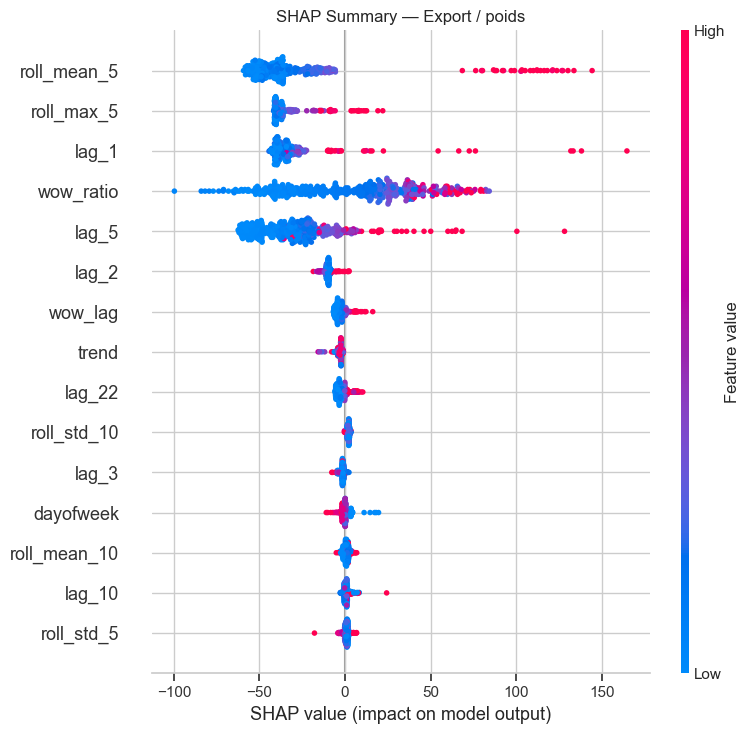

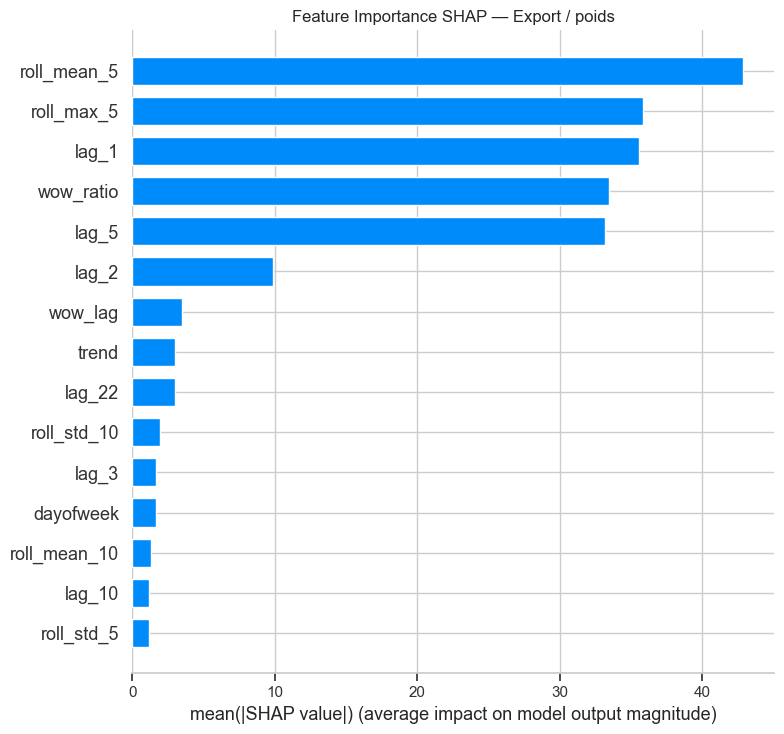

SHAP — Export / CA


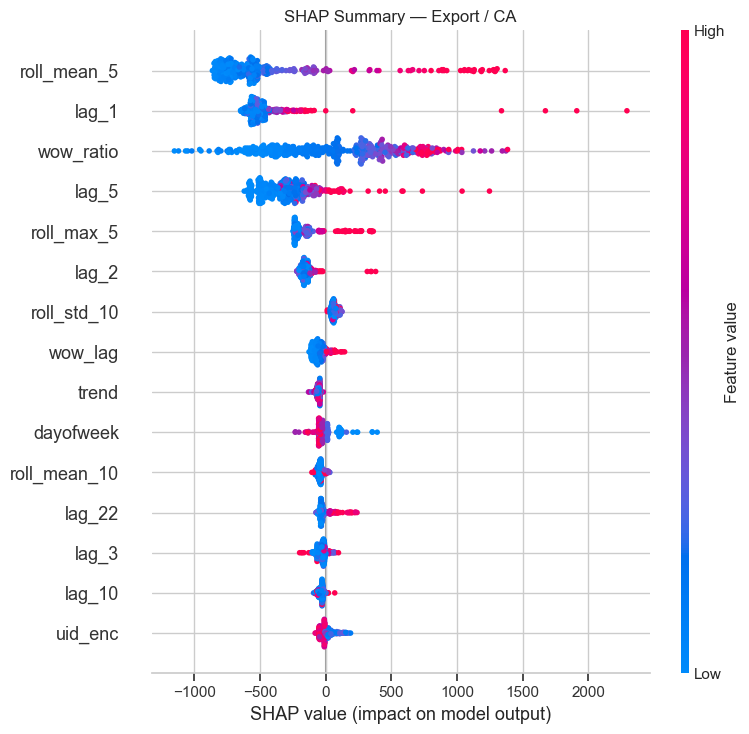

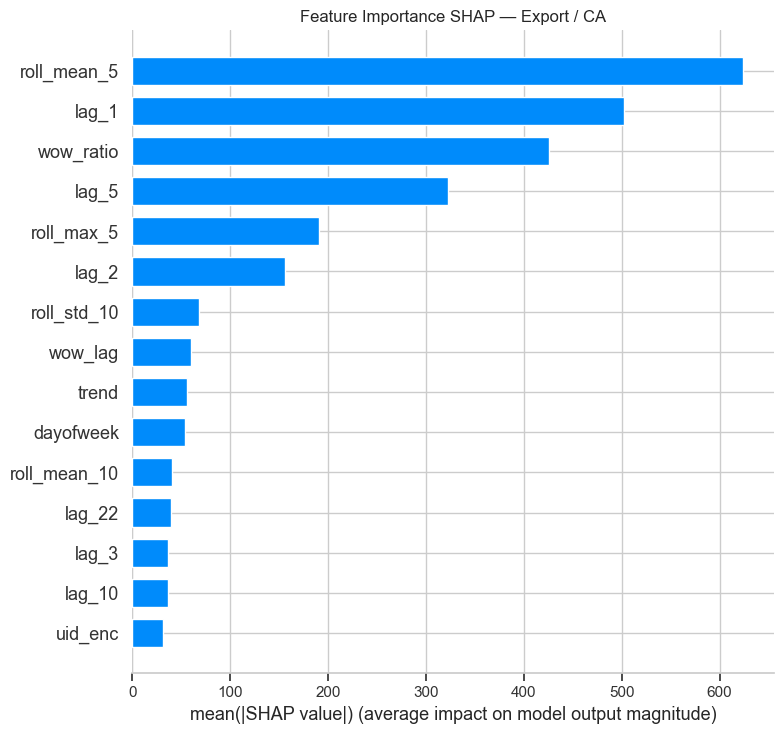

SHAP — National / poids


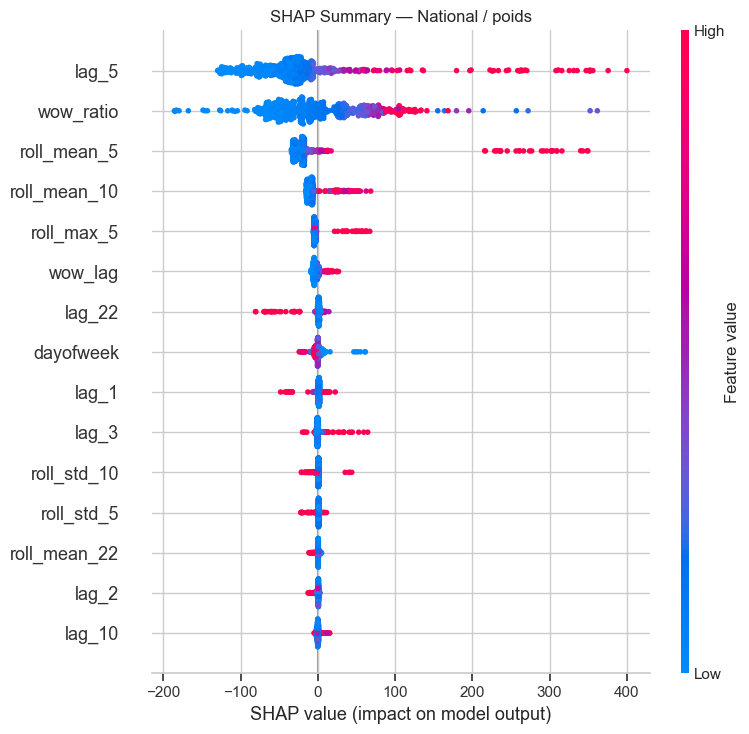

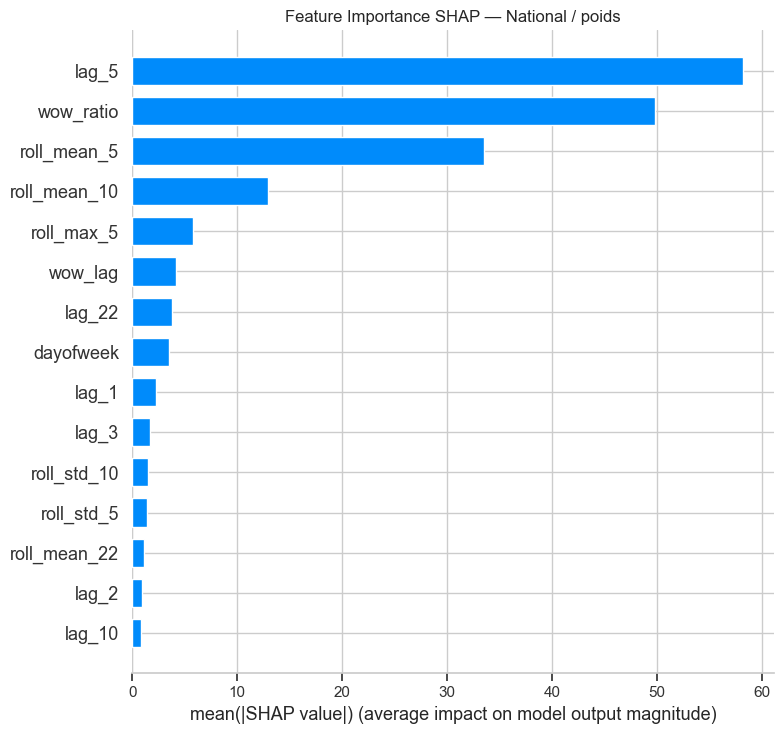

SHAP — National / CA


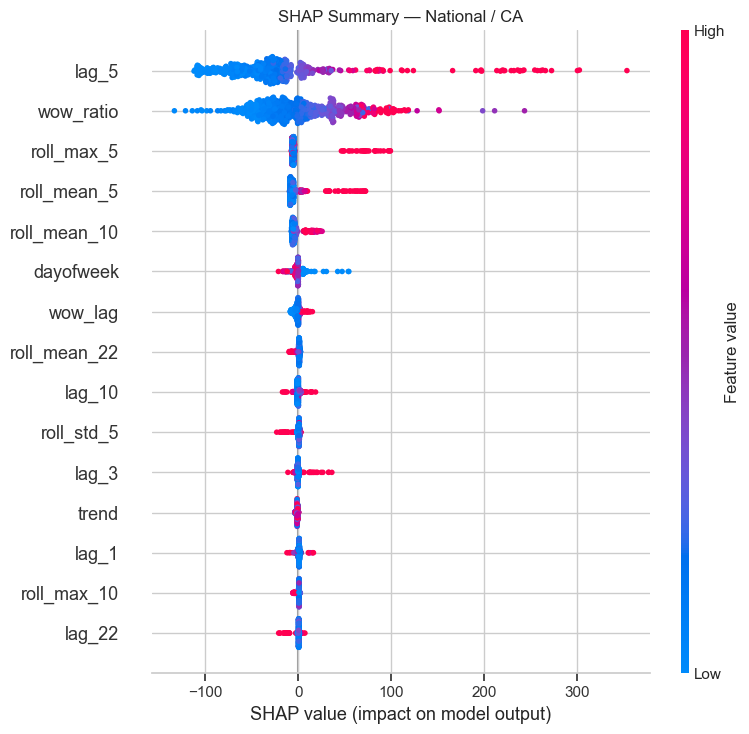

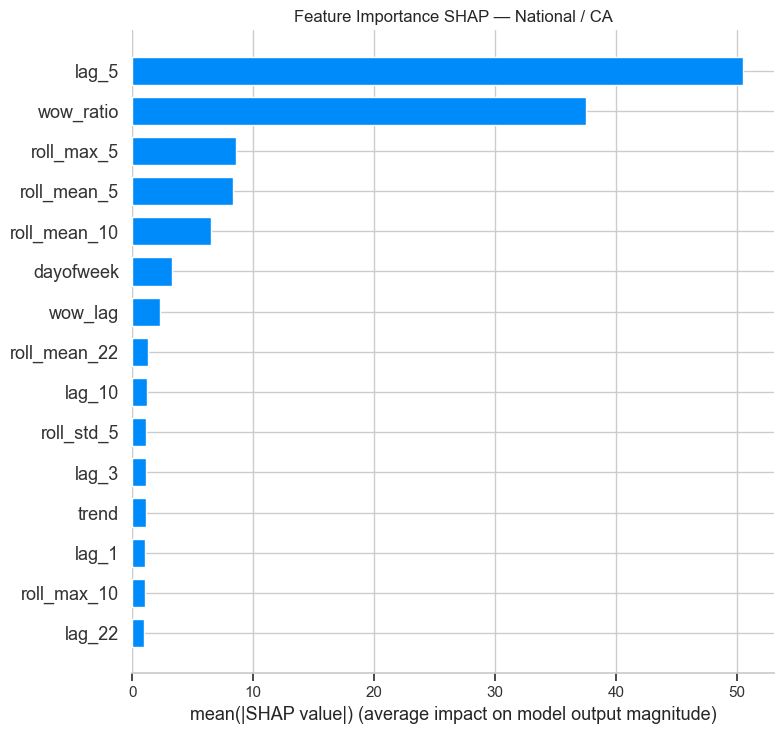

SHAP — Import / poids


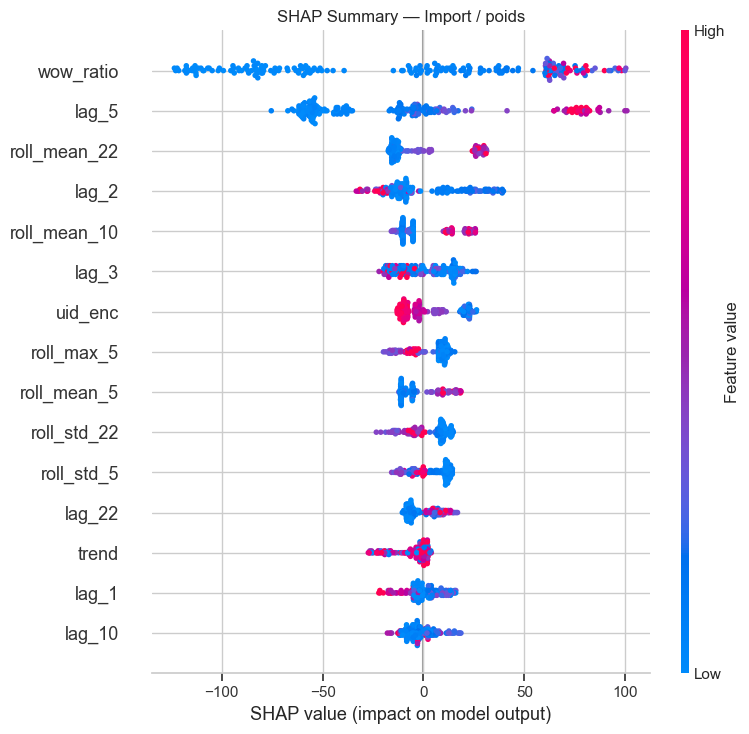

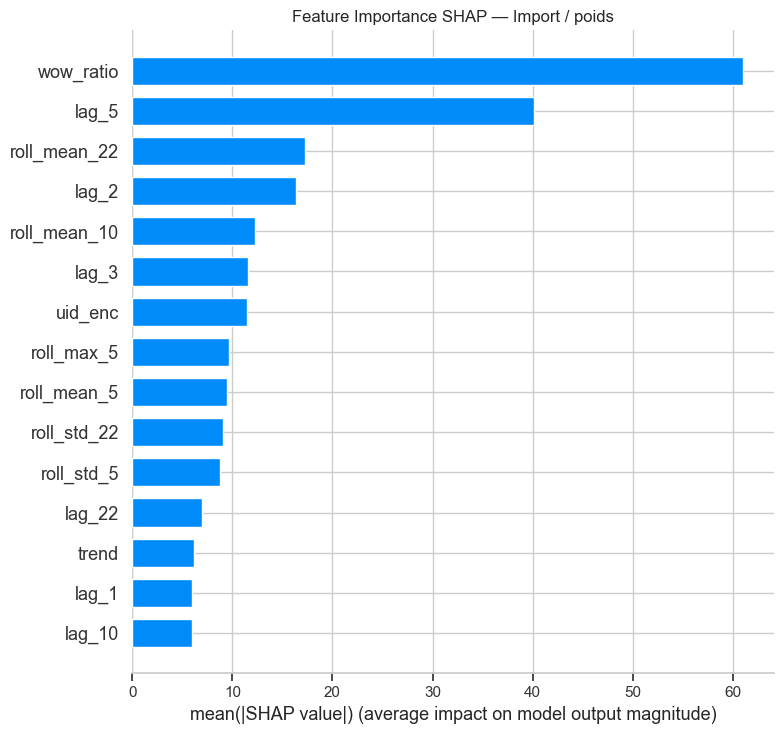

In [26]:
def run_shap(key, dataset_name, target):
    tm = ML_MODELS.get(key, {})
    if not tm or 'LightGBM' not in tm:
        print(f'  No LightGBM for {key}. Skipping SHAP.')
        return
    model, feat_cols, df_test = tm['LightGBM']
    X_test = df_test[feat_cols].values
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    print(f'SHAP — {dataset_name} / {target}')
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=feat_cols,
                      show=False, max_display=15)
    plt.title(f'SHAP Summary — {dataset_name} / {target}')
    plt.tight_layout()
    plt.savefig(f'shap_{dataset_name}_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()
    shap.summary_plot(shap_values, X_test, feature_names=feat_cols,
                      plot_type='bar', show=False, max_display=15)
    plt.title(f'Feature Importance SHAP — {dataset_name} / {target}')
    plt.tight_layout(); plt.show()

run_shap('Export_poids',   'Export',   'poids')
run_shap('Export_CA',      'Export',   'CA')
run_shap('National_poids', 'National', 'poids')
run_shap('National_CA',    'National', 'CA')
run_shap('Import_poids',   'Import',   'poids')

---
## Partie 13 — Prévision Future (12 Mois)

In [27]:
def forecast_future(df_daily, target, dataset_name, horizon=HORIZON_FUT):
    if target not in df_daily.columns: return pd.DataFrame()
    print(f'\nFuture forecast -- {dataset_name} / {target}')
    ndf = to_nixtla(df_daily, target)
    if len(ndf) == 0: return pd.DataFrame()
    n_days = ndf['ds'].nunique()
    season_len = 5 if n_days >= 10 else 1
    sf_models = [AutoARIMA(season_length=season_len),
                 AutoTheta(season_length=season_len)]
    sf = StatsForecast(
        models=sf_models, freq='B', n_jobs=-1,
        fallback_model=AutoTheta(season_length=1)
    )
    sf.fit(ndf)
    fut = sf.predict(h=horizon, level=[80, 95])
    fut['dataset'] = dataset_name
    fut['target']  = target
    for col in ['AutoARIMA', 'AutoTheta']:
        if col in fut.columns:
            fut['forecast'] = fut[col].clip(lower=0)
            break
    print(f'  {fut["ds"].min().date()} -> {fut["ds"].max().date()} ({horizon} business days)')
    return fut

fut_exp_poids   = forecast_future(df_export,   'poids', 'Export')
fut_exp_ca      = forecast_future(df_export,   'CA',    'Export')
fut_nat_poids   = forecast_future(df_national, 'poids', 'National')
fut_nat_ca      = forecast_future(df_national, 'CA',    'National')
fut_imp_poids   = forecast_future(df_import,   'poids', 'Import')

all_futures = pd.concat(
    [f for f in [fut_exp_poids, fut_exp_ca, fut_nat_poids, fut_nat_ca, fut_imp_poids]
     if not f.empty], ignore_index=True)
all_futures.to_csv('forecasts_60bd.csv', index=False)
print('Saved -> forecasts_60bd.csv')


Future forecast -- Export / poids
  Nixtla -> 1,501 rows | 28 series
  2026-04-14 -> 2026-07-23 (60 business days)

Future forecast -- Export / CA
  Nixtla -> 1,501 rows | 28 series
  2026-04-14 -> 2026-07-23 (60 business days)

Future forecast -- National / poids
  Nixtla -> 1,897 rows | 24 series
  2026-04-30 -> 2026-07-23 (60 business days)

Future forecast -- National / CA
  Nixtla -> 1,897 rows | 24 series
  2026-04-30 -> 2026-07-23 (60 business days)

Future forecast -- Import / poids
  Nixtla -> 785 rows | 22 series
  2026-04-07 -> 2026-07-23 (60 business days)
Saved -> forecasts_60bd.csv


In [28]:
def plot_future(df_monthly, fut_df, target, dataset_name, top_n=6):
    if fut_df.empty or target not in df_monthly.columns: return
    top_ids = (df_monthly.groupby('unique_id')[target].sum()
               .nlargest(top_n).index.tolist())
    hist  = df_monthly[df_monthly['unique_id'].isin(top_ids)]
    fcast = fut_df[fut_df['unique_id'].isin(top_ids)]
    n_cols = 2
    n_rows = (top_n + 1) // n_cols
    fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=top_ids)
    colors = px.colors.qualitative.Plotly
    for idx, uid in enumerate(top_ids):
        r, c = divmod(idx, n_cols)
        row, col = r + 1, c + 1
        clr = colors[idx % len(colors)]
        h = hist[hist['unique_id'] == uid]
        fig.add_trace(go.Scatter(
            x=h['ds'], y=h[target], name=uid,
            line=dict(color=clr, width=2), showlegend=False
        ), row=row, col=col)
        f = fcast[fcast['unique_id'] == uid]
        if not f.empty and 'forecast' in f.columns:
            fig.add_trace(go.Scatter(
                x=f['ds'], y=f['forecast'],
                name=f'Prévision', line=dict(color=clr, width=2, dash='dot'),
                showlegend=False
            ), row=row, col=col)
            lo = [x for x in f.columns if 'lo-80' in x.lower() or 'lo_80' in x.lower()]
            hi = [x for x in f.columns if 'hi-80' in x.lower() or 'hi_80' in x.lower()]
            if lo and hi:
                fig.add_trace(go.Scatter(
                    x=pd.concat([f['ds'], f['ds'][::-1]]),
                    y=pd.concat([f[hi[0]], f[lo[0]][::-1]]),
                    fill='toself', fillcolor='rgba(100,100,255,0.15)',
                    line=dict(color='rgba(0,0,0,0)'),
                    name='IC 80%', showlegend=False
                ), row=row, col=col)
    fig.update_layout(
        title=f'{dataset_name} — {target} : Historique + Prévision 12 Mois',
        height=320 * n_rows, template='plotly_white'
    )
    fig.show()
    fig.write_html(f'forecast_{dataset_name}_{target}.html')
    print(f'Saved → forecast_{dataset_name}_{target}.html')

plot_future(df_export,   fut_exp_poids, 'poids', 'Export')
plot_future(df_export,   fut_exp_ca,    'CA',    'Export')
plot_future(df_national, fut_nat_poids, 'poids', 'National')
plot_future(df_national, fut_nat_ca,    'CA',    'National')
plot_future(df_import,   fut_imp_poids, 'poids', 'Import')

Saved → forecast_Export_poids.html


Saved → forecast_Export_CA.html


Saved → forecast_National_poids.html


Saved → forecast_National_CA.html


Saved → forecast_Import_poids.html


In [29]:
def plot_global_forecast(df_monthly, fut_df, target, dataset_name):
    if fut_df.empty or target not in df_monthly.columns: return
    hist_total  = df_monthly.groupby('ds')[target].sum().reset_index()
    fcast_total = fut_df.groupby('ds')['forecast'].sum().reset_index() if 'forecast' in fut_df.columns else pd.DataFrame()
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=hist_total['ds'], y=hist_total[target],
        name='Historique', line=dict(color='steelblue', width=2.5)
    ))
    if not fcast_total.empty:
        fig.add_trace(go.Scatter(
            x=fcast_total['ds'], y=fcast_total['forecast'],
            name='Prévision 12 mois', line=dict(color='crimson', width=2.5, dash='dot')
        ))
    fig.update_layout(
        title=f'{dataset_name} — {target} Total (tous pays/régions)',
        xaxis_title='Date', yaxis_title=target,
        template='plotly_white'
    )
    fig.show()
    fig.write_html(f'global_{dataset_name}_{target}.html')

plot_global_forecast(df_export,   fut_exp_poids, 'poids', 'Export')
plot_global_forecast(df_export,   fut_exp_ca,    'CA',    'Export')
plot_global_forecast(df_national, fut_nat_poids, 'poids', 'National')
plot_global_forecast(df_national, fut_nat_ca,    'CA',    'National')
plot_global_forecast(df_import,   fut_imp_poids, 'poids', 'Import')

In [30]:
print('=== OUTPUT FILES GENERATED ===')
output_files = [
    'export_cleaned.csv', 'national_cleaned.csv', 'import_cleaned.csv',
    'model_comparison.csv', 'forecasts_12months.csv',
]
for f in output_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {f} ({size:,} bytes)')

html_files = [f for f in os.listdir('.') if f.endswith('.html')]
for f in sorted(html_files):
    print(f'  [HTML] {f}')

png_files = [f for f in os.listdir('.') if f.startswith('shap_') and f.endswith('.png')]
for f in sorted(png_files):
    print(f'  [PNG]  {f}')

=== OUTPUT FILES GENERATED ===
  [OK] export_cleaned.csv (79,728 bytes)
  [OK] national_cleaned.csv (77,257 bytes)
  [OK] import_cleaned.csv (33,025 bytes)
  [OK] model_comparison.csv (3,216 bytes)
  [MISSING] forecasts_12months.csv (0 bytes)
  [HTML] forecast_Export_CA.html
  [HTML] forecast_Export_poids.html
  [HTML] forecast_Import_poids.html
  [HTML] forecast_National_CA.html
  [HTML] forecast_National_poids.html
  [HTML] global_Export_CA.html
  [HTML] global_Export_poids.html
  [HTML] global_Import_poids.html
  [HTML] global_National_CA.html
  [HTML] global_National_poids.html
  [PNG]  shap_Export_CA.png
  [PNG]  shap_Export_poids.png
  [PNG]  shap_Import_poids.png
  [PNG]  shap_National_CA.png
  [PNG]  shap_National_poids.png
